In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
code_dir = f'{os.getenv('HOME')}/cai-dr2-clustering-products/clustering_statistics/'
sys.path.insert(0,code_dir)
import tools
import plotting_tools

In [3]:
plot_dir = Path('_plots')
plot_dir.mkdir(exist_ok=True)
ext = 'png'

In [4]:
!tree -d -L 3 $tools.base_stats_dir | grep -vE '(complete)'

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics
├── auxiliary_data
├── bao
│   └── base
├── box
│   └── abacus-2ndgen
├── full_shape
│   ├── base
│   │   ├── abacus-2ndgen-dr2-altmtl
│   │   ├── abacus-hf-dr2-v2-altmtl
│   │   ├── glam-uchuu-bgs-altmtl
│   │   ├── glam-uchuu-v1-altmtl
│   │   ├── glam-uchuu-v2-altmtl
│   │   ├── holi-bgs-altmtl
│   │   ├── holi-v1-altmtl
│   │   ├── holi-v3-altmtl
│   │   └── uchuu-hf-altmtl
│   ├── box_window_function_validation
│   │   └── abacus-hf-v2
│   ├── data_splits
│   │   ├── abacus-hf-dr2-v2-altmtl
│   │   ├── blinded_data
│   │   ├── glam-uchuu-v2-altmtl
│   │   └── holi-v3-altmtl
│   ├── fiber_assignment_systematics
│   │   ├── abacus-2ndgen-dr2-altmtl
│   │   └── abacus-hf-dr2-v2-altmtl
│   └── multitracer
│       ├── abacus-hf-dr2-v2-altmtl
│       ├── abacus-hf-dr2-v2-box
│       ├── archive
│       ├── _emulators
│       └── holi-v3-altmtl
├── local_png
│   ├── base
│   │   ├── desi-data
│   │   ├── glam-uchuu

# Plot latest measurements (dark)

In [5]:
analysis = 'full_shape'
project = f'{analysis}/base'
region  = 'GCcomb'
tracers = ['LRG', 'ELG_LOPnotqso', 'QSO']

stats_dir = Path(str(tools.base_stats_dir).replace('global','dvs_ro'))

ells4pk = (0,2)
ells4xi = [0,2,4]
ells4bk = ((0,0,0), (2,0,2))

In [6]:
# some mocks to exclude
# imocks = np.arange(1500)
# bad_imocks = np.concatenate([300+np.arange(50),[202, 203, 205, 211]])
# bad_imocks = np.concatenate([350+np.arange(50),[280,1275]])
# glam_imocks = imocks[~np.isin(imocks,bad_imocks)]

# get mock indices to use for mock covariance estimation
glam_imocks = np.loadtxt('../helper_scripts/glam-uchuu-v2-altmtl_dark-time_imocks_for_covariance.txt',dtype=int)
holi_imocks = np.loadtxt('../helper_scripts/holi-v3-altmtl_dark-time_imocks_for_covariance.txt',dtype=int)
print(len(glam_imocks),len(holi_imocks))

878 859


In [7]:
# measumerents to compare
reference = 'glam-uchuu-v2-altmtl' # what we compare against in the figures below
cases = {'glam-uchuu-v2-altmtl': {'version': 'glam-uchuu-v2-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': glam_imocks},
         # 'glam-uchuu-v1-altmtl':   {'version': 'glam-uchuu-v1-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': None},
         # 'holi-v1-altmtl':   {'version': 'holi-v1-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': None},
         'holi-v3-altmtl': {'version': 'holi-v3-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': holi_imocks},
         'abacus-2ndgen-dr2-complete': {'version': 'abacus-2ndgen-dr2-complete', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': None},
         'abacus-2ndgen-dr2-altmtl': {'version': 'abacus-2ndgen-dr2-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': None},
         'abacus-hf-dr2-v2-altmtl': {'version': 'abacus-hf-dr2-v2-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': None},
         # 'uchuu-hf-altmtl':   {'version': 'uchuu-hf-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': None},
        }
# colors and linestyles
colors = dict(zip(cases, [f'C{i}' for i in range(len(cases))]))
linestyles = dict(zip(cases, ['-', '--','-.',':',':',':',':']))

/global/homes/a/arosado/cai-dr2-clustering-products/clustering_statistics/plotting_tools.py:127: RuntimeWarning: invalid value encountered in divide
  ax.plot(pole.coords('k'), (pole.value() - pole_reference.value()).real / std, color=colors[version], linestyle=linestyles[version], lw=lw)


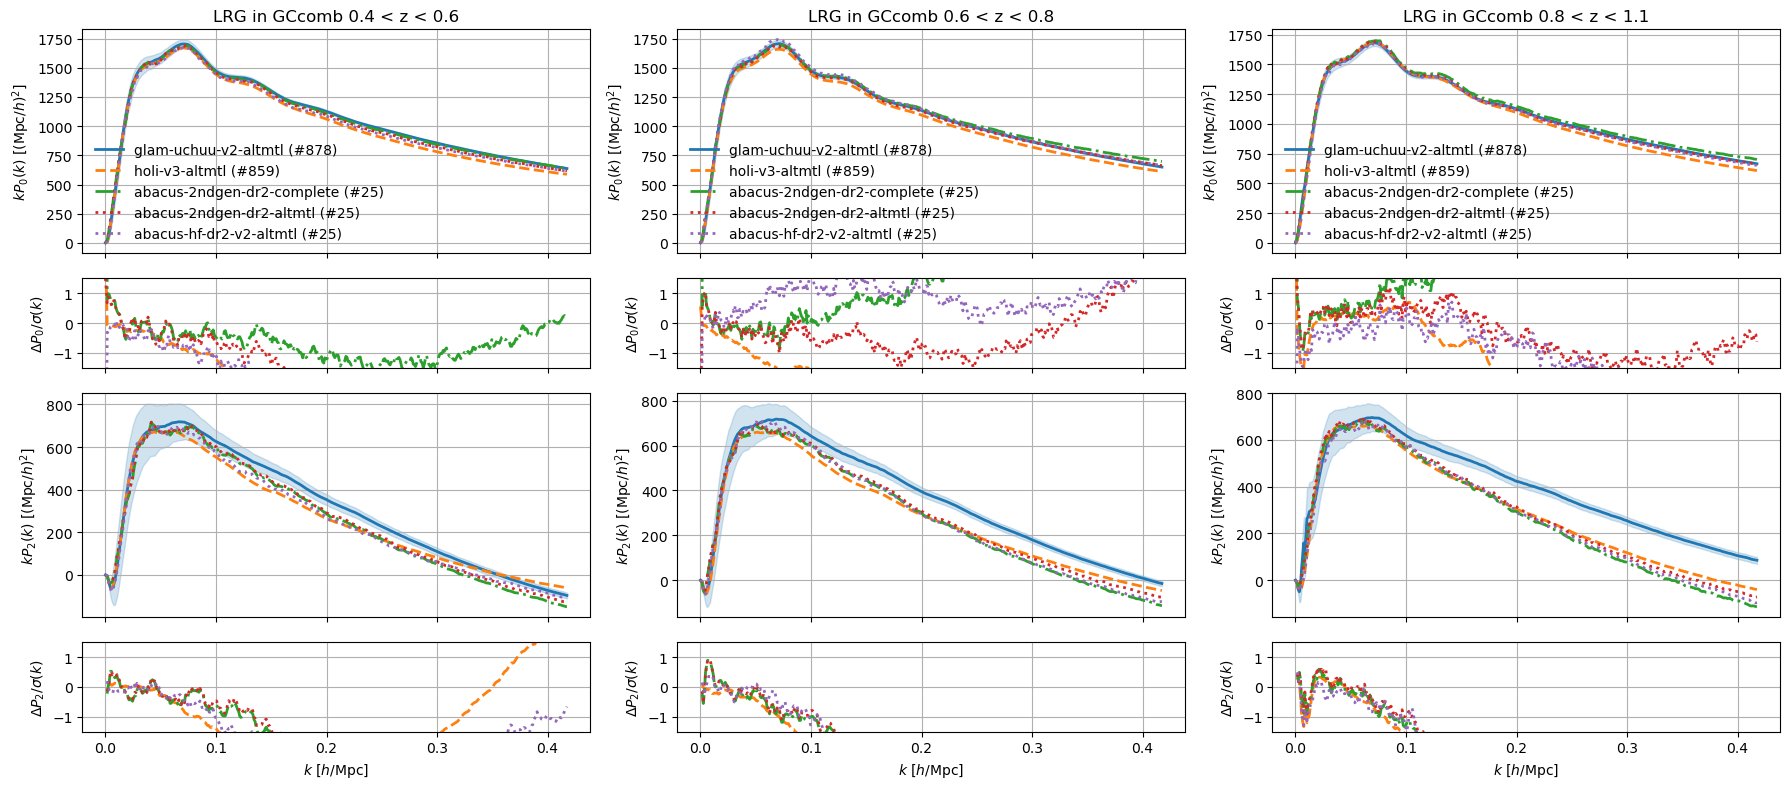

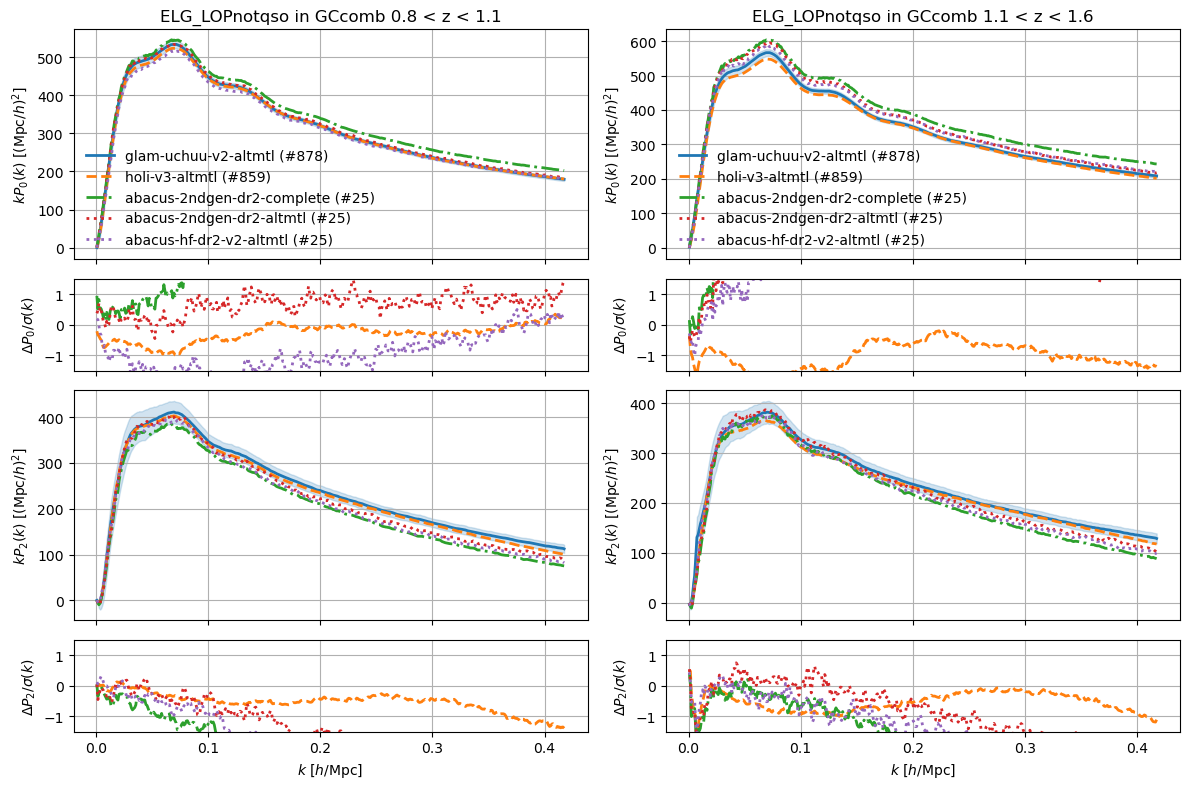

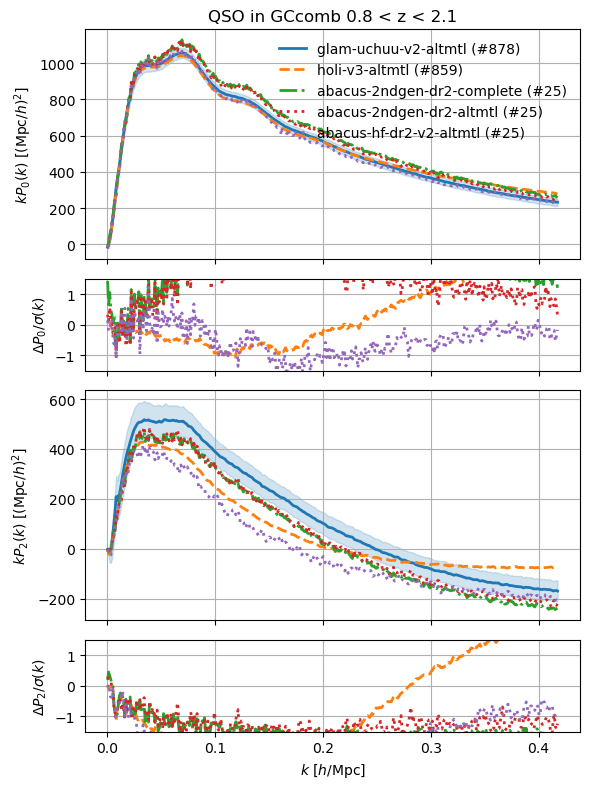

In [8]:
# figures with power spectra
scaling='kpk'
# scaling='loglog'

plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project,legend_ncol=1)
for tracer in tracers:
    zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
    nrows  = len(ells4pk) * 2
    ncols  = len(zranges)
    figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4pk)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4pk)})
    for iz, zrange in enumerate(zranges):    
        plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells4pk)
        plotting_tools.plot_stats('mesh2_spectrum', cases, tracer, zrange, region, **plot_kws)
    plt.tight_layout()
    basename = f'checks_pk_{tracer}_{region}.{ext}'
    # figure[0].savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()
    print()

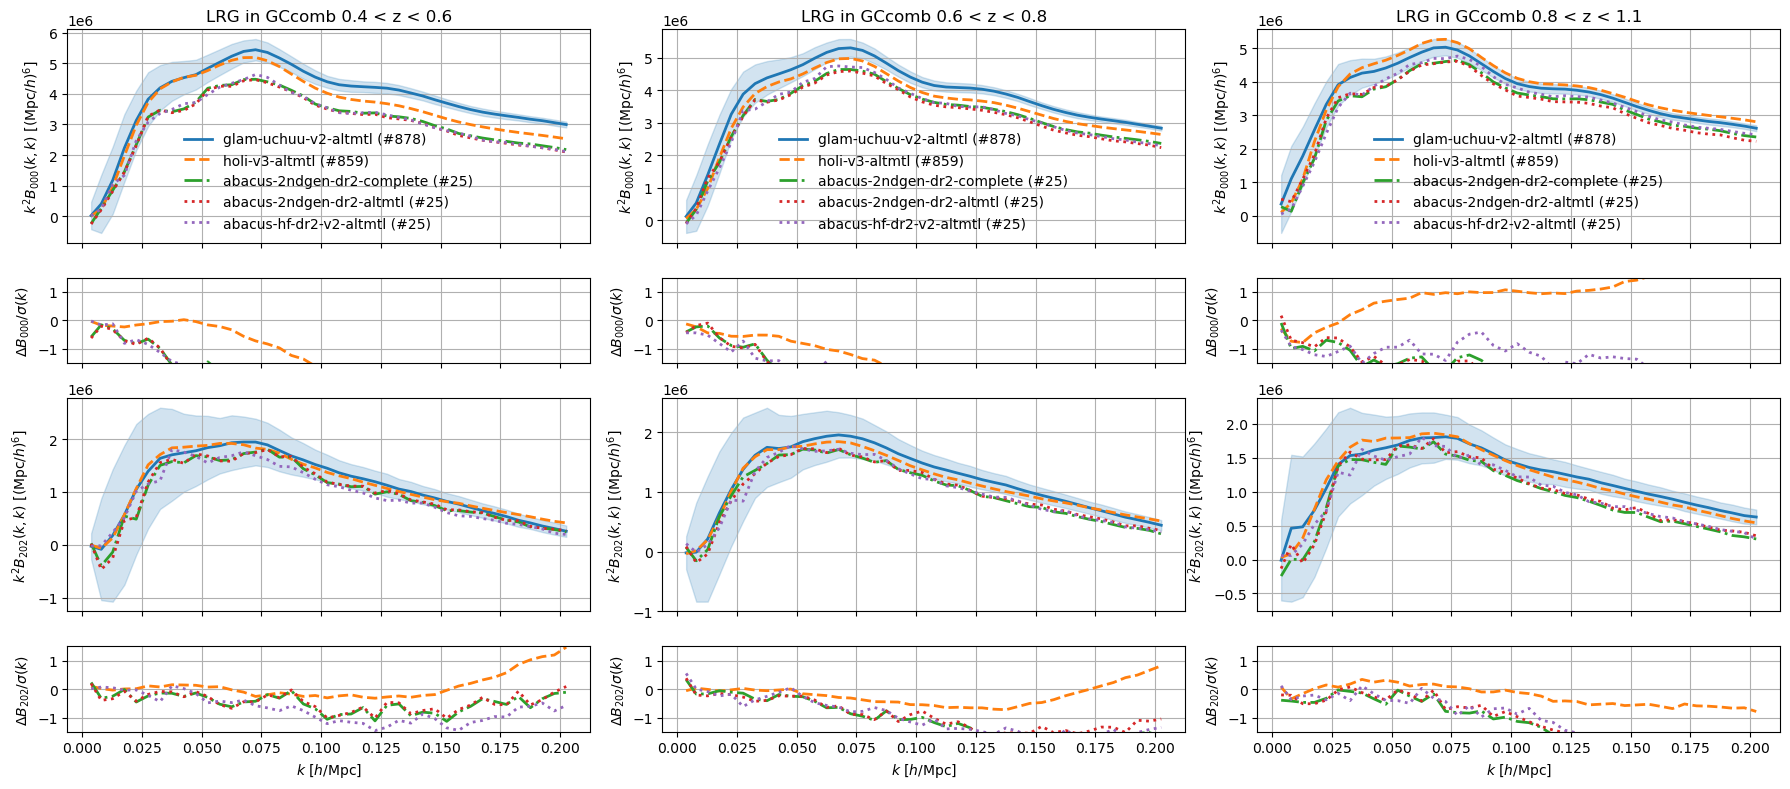

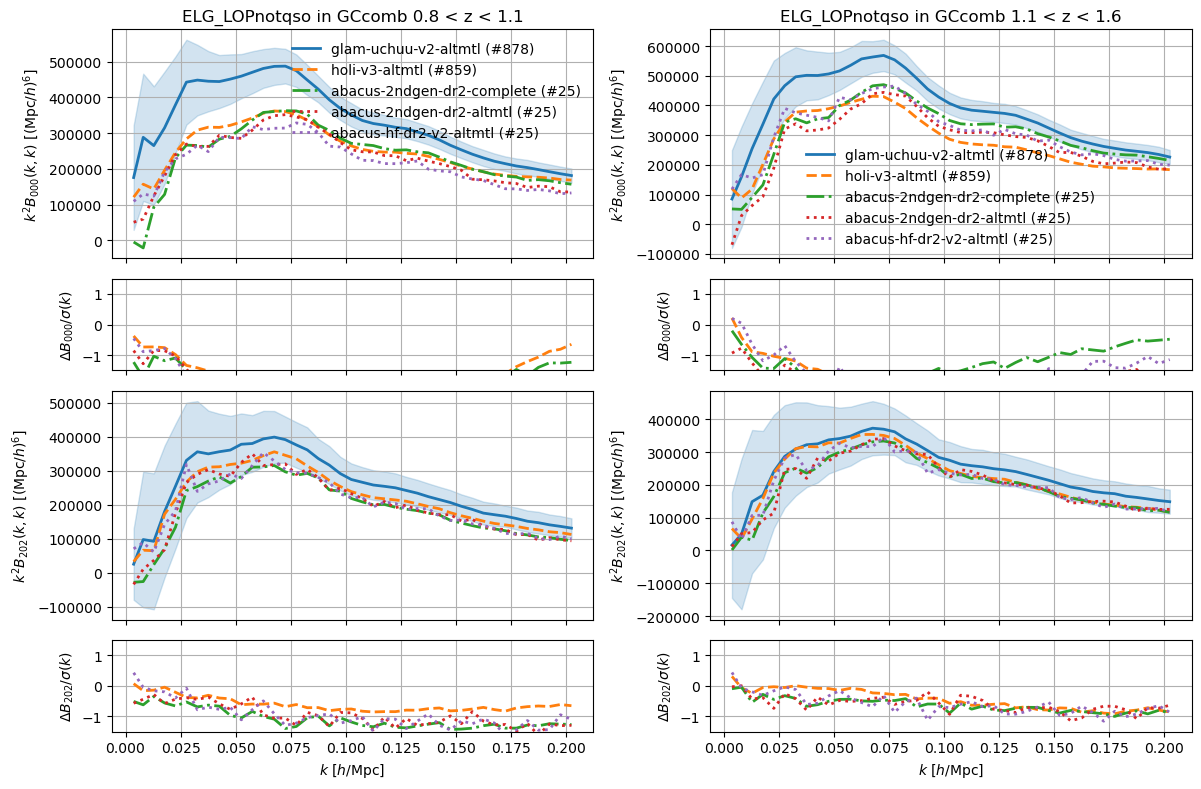

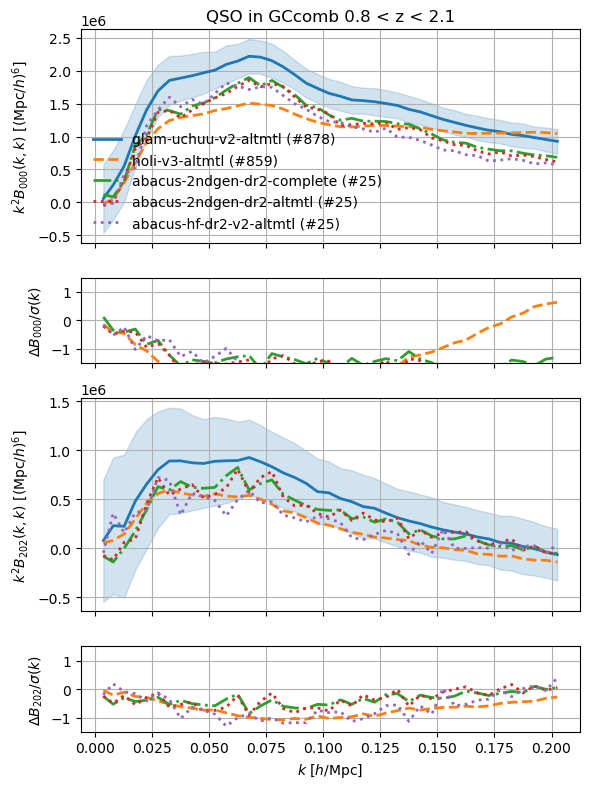

In [9]:
# figures with bispectra
scaling='kpk'
# scaling='loglog'
colors = dict(zip(cases, [f'C{i}' for i in range(len(cases))]))
linestyles = dict(zip(cases, ['-', '--','-.',':',':',':']))
plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project)

for tracer in tracers:
    zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
    nrows  = len(ells4bk) * 2
    ncols  = len(zranges)
    figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4bk)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4bk)})
    for iz, zrange in enumerate(zranges):    
        plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells4bk)
        plotting_tools.plot_stats('mesh3_spectrum_sugiyama-diagonal', cases, tracer, zrange, region, **plot_kws)
    plt.tight_layout()
    basename = f'checks_bk_{tracer}_{region}.{ext}'
    # figure[0].savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()

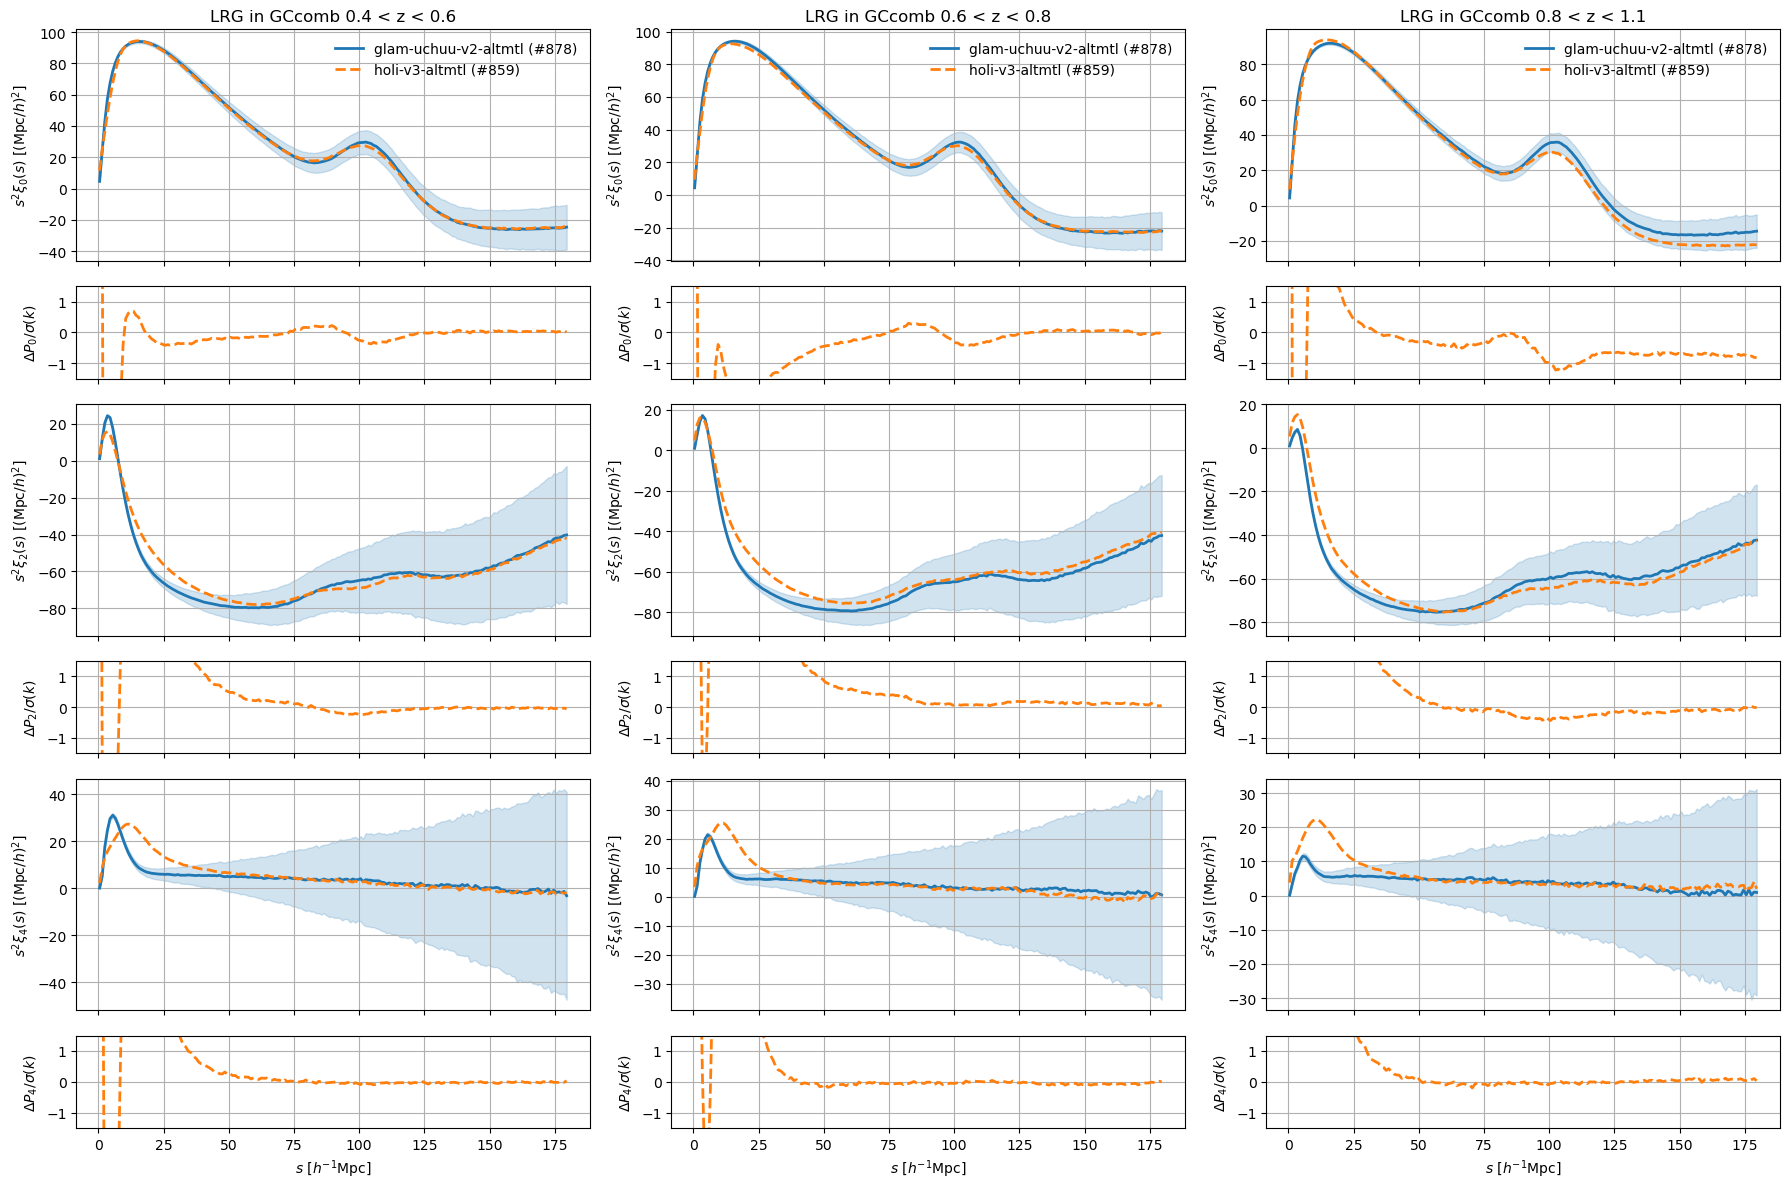

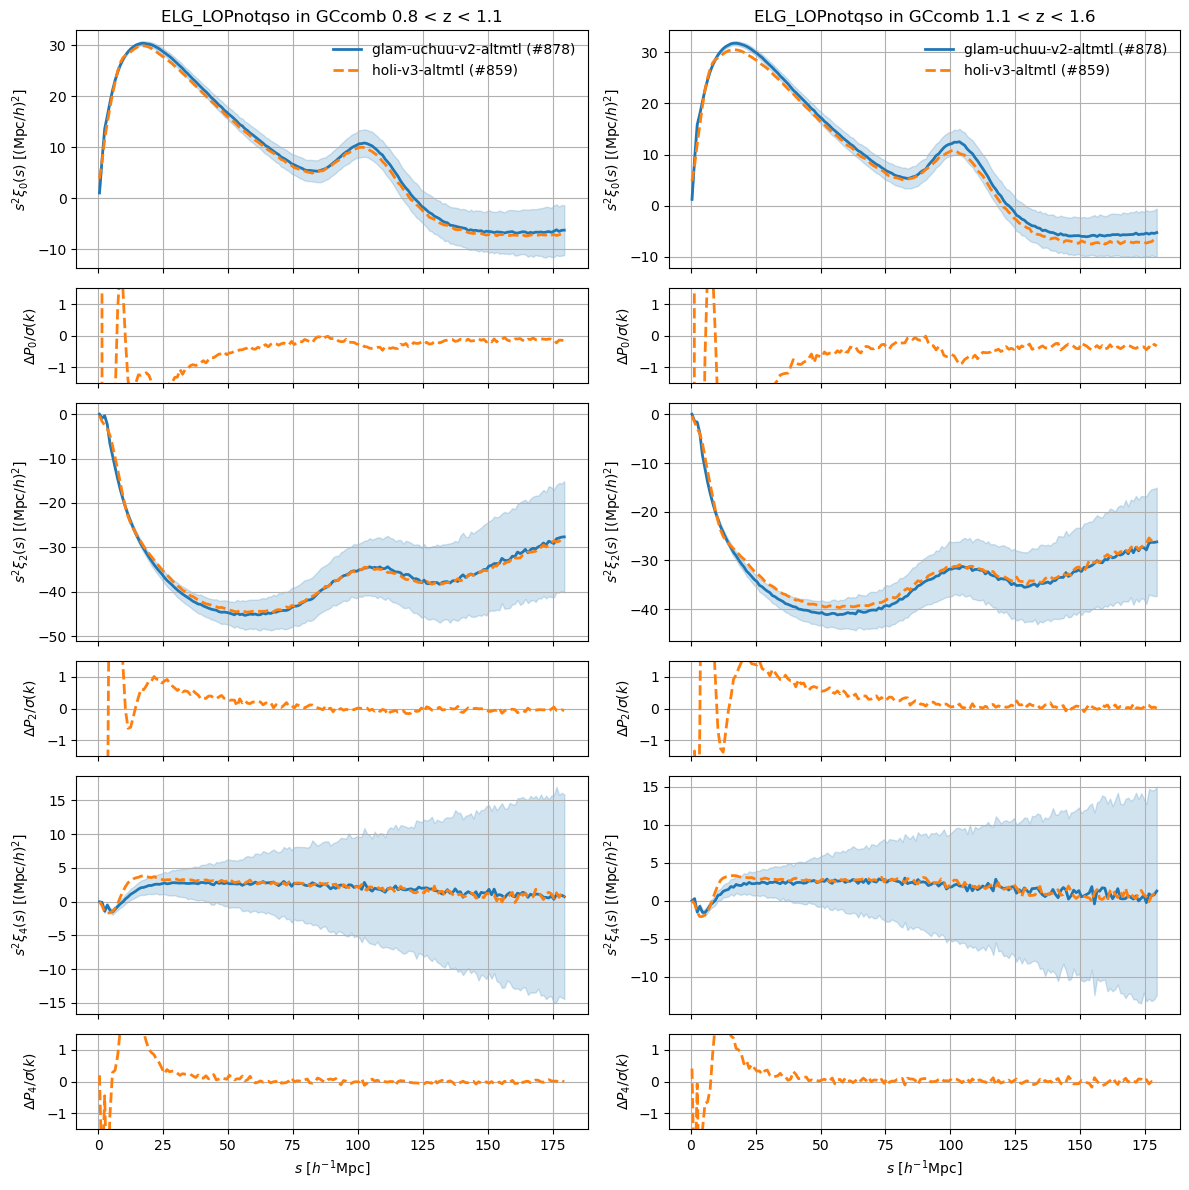

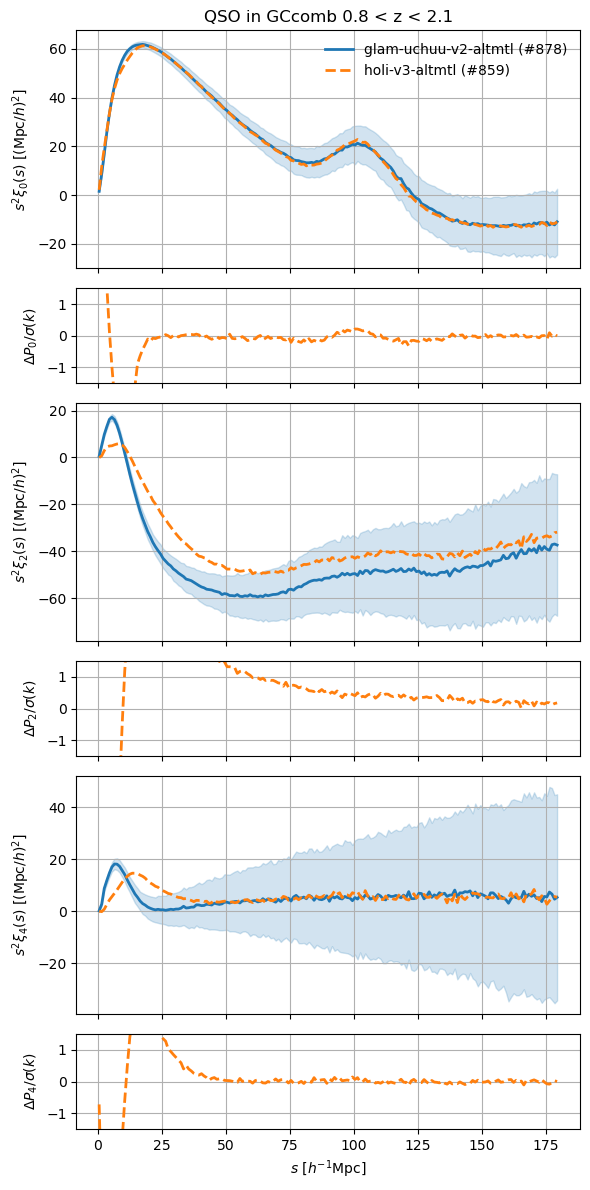

In [11]:
# figures with 2PCF
reference = 'glam-uchuu-v2-altmtl'
cases = {'glam-uchuu-v2-altmtl':   {'version': 'glam-uchuu-v2-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': glam_imocks},
         'holi-v3-altmtl':   {'version': 'holi-v3-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': None}}

plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project,legend_ncol=1)
for tracer in tracers:
    zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
    nrows  = len(ells4xi) * 2
    ncols  = len(zranges)
    figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4xi)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4xi)})
    for iz, zrange in enumerate(zranges):    
        plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells4xi)
        plotting_tools.plot_stats('particle2_correlation', cases, tracer, zrange, region, **plot_kws)
    plt.tight_layout()
    basename = f'checks_xi_{tracer}_{region}.{ext}'
    # figure[0].savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()

# Plot latest measurements (bright)

In [6]:
analysis = 'full_shape'
project = f'{analysis}/base'
region  = 'GCcomb'
tracers = ['BGS_BRIGHT-21.35']

stats_dir = Path(str(tools.base_stats_dir).replace('global','dvs_ro'))

ells4pk = (0,2)
ells4xi = [0,2,4]
ells4bk = ((0,0,0), (2,0,2))

In [9]:
# measurements to compare
reference = 'glam-uchuu-bgs-altmtl' # what we compare against in the figures below
cases = {'glam-uchuu-bgs-altmtl': {'version': 'glam-uchuu-bgs-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': None},
         'holi-bgs-altmtl': {'version': 'holi-bgs-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': None}}
# colors and linestyles
colors = dict(zip(cases, [f'C{i}' for i in range(len(cases))]))
linestyles = dict(zip(cases, ['-', '--','-.',':',':',':',':']))

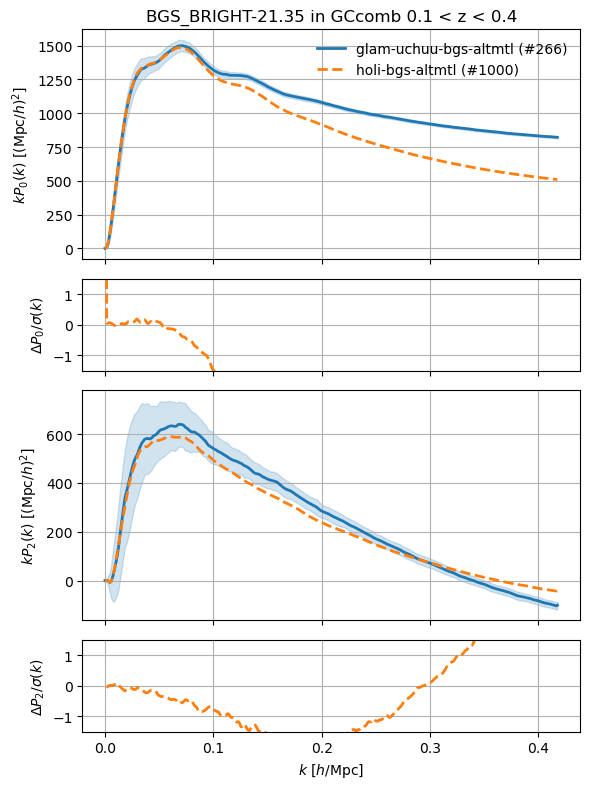

In [10]:
# figures with power spectra
scaling='kpk'
# scaling='loglog'

plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project,legend_ncol=1)
for tracer in tracers:
    zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
    nrows  = len(ells4pk) * 2
    ncols  = len(zranges)
    figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4pk)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4pk)})
    for iz, zrange in enumerate(zranges):    
        plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells4pk)
        plotting_tools.plot_stats('mesh2_spectrum', cases, tracer, zrange, region, **plot_kws)
    plt.tight_layout()
    basename = f'checks_pk_{tracer}_{region}.{ext}'
    figure[0].savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()
    print()

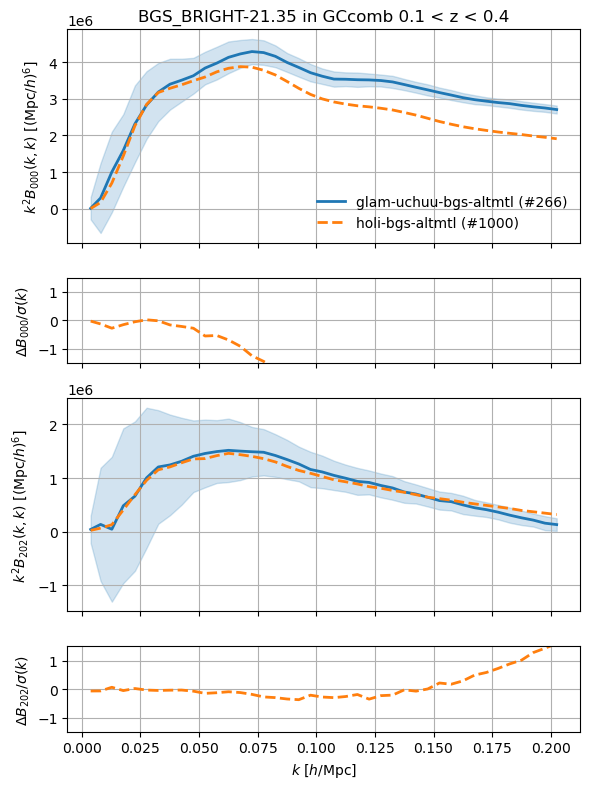

In [11]:
# figures with bispectra
scaling='kpk'
# scaling='loglog'
plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project)

for tracer in tracers:
    zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
    nrows  = len(ells4bk) * 2
    ncols  = len(zranges)
    figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4bk)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4bk)})
    for iz, zrange in enumerate(zranges):    
        plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells4bk)
        plotting_tools.plot_stats('mesh3_spectrum_sugiyama-diagonal', cases, tracer, zrange, region, **plot_kws)
    plt.tight_layout()
    basename = f'checks_bk_{tracer}_{region}.{ext}'
    figure[0].savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()

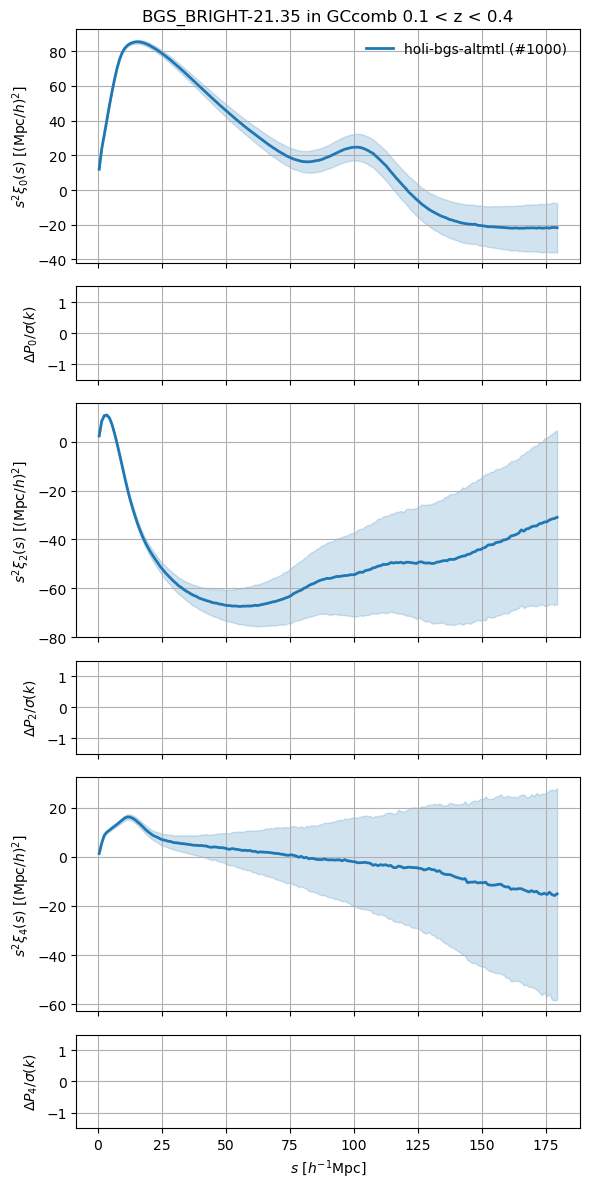

In [7]:
# measurements to compare
reference = 'holi-bgs-altmtl' # what we compare against in the figures below
cases = {'holi-bgs-altmtl': {'version': 'holi-bgs-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': None}}
# colors and linestyles
colors = dict(zip(cases, [f'C{i}' for i in range(len(cases))]))
linestyles = dict(zip(cases, ['-', '--','-.',':',':',':',':']))

# figures with 2PCF
scaling='kpk'
plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project)

for tracer in tracers:
    zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
    nrows  = len(ells4xi) * 2
    ncols  = len(zranges)
    figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4xi)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4xi)})
    for iz, zrange in enumerate(zranges):    
        plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells4xi)
        plotting_tools.plot_stats('particle2_correlation', cases, tracer, zrange, region, **plot_kws)
    plt.tight_layout()
    basename = f'checks_xi_{tracer}_{region}.{ext}'
    # figure[0].savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()

# Check for available measurements

In [15]:
# check for available measurements
region = 'GAL060'
analysis = 'full_shape'
stats_dir = Path(str(tools.base_stats_dir).replace('global','dvs_ro'))
# project = f'{analysis}/base'
project = f'{analysis}/data_splits'
for tracer in ['LRG', 'ELG_LOPnotqso', 'QSO']:
    # for version in ['holi-v3-altmtl','glam-uchuu-v1-altmtl', 'glam-uchuu-v2-altmtl', 'abacus-2ndgen-dr2-complete','abacus-2ndgen-dr2-altmtl']:
    for version in ['glam-uchuu-v2-altmtl']:
        if 'ELG' in tracer:
            if 'complete' in version:
                tracer = 'ELG_LOP'
            else:
                tracer = 'ELG_LOPnotqso'
        for zrange in tools.propose_fiducial('zranges',tracer, analysis=analysis):
            fn = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum',
                                    version=version, tracer=tracer,
                                    zrange=zrange, region=region, weight='default-FKP', imock='*')
            print(tracer, version, zrange, 'mesh2_spectrum',len(fn))
        print()
    print()

LRG glam-uchuu-v2-altmtl (0.4, 0.6) mesh2_spectrum 50
LRG glam-uchuu-v2-altmtl (0.6, 0.8) mesh2_spectrum 50
LRG glam-uchuu-v2-altmtl (0.8, 1.1) mesh2_spectrum 50


ELG_LOPnotqso glam-uchuu-v2-altmtl (0.8, 1.1) mesh2_spectrum 50
ELG_LOPnotqso glam-uchuu-v2-altmtl (1.1, 1.6) mesh2_spectrum 50


QSO glam-uchuu-v2-altmtl (0.8, 2.1) mesh2_spectrum 50




In [5]:
# check for available measurements
region = 'GCcomb'
# region = 'SGC'
analysis = 'full_shape'
stats_dir = Path(str(tools.base_stats_dir).replace('global','dvs_ro'))
project = f'{analysis}/base'


versions = ['holi-bgs-altmtl']
for tracer in ['BGS_BRIGHT-21.35']:
    for version in versions:
        if 'ELG' in tracer:
            if 'complete' in version:
                tracer = 'ELG_LOP'
            else:
                tracer = 'ELG_LOPnotqso'
        for zrange in tools.propose_fiducial('zranges',tracer, analysis=analysis):
            fn = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum',
                                    version=version, tracer=tracer,
                                    zrange=zrange, region=region, weight='default-FKP', imock='*')
            print(tracer, version, zrange, 'mesh2_spectrum',len(fn))
    
            fn = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh3_spectrum', basis='sugiyama-diagonal', 
                                    version=version, tracer=tracer,
                                    zrange=zrange, region=region, weight='default-FKP', imock='*')
            print(tracer, version, zrange, 'mesh3_spectrum-sugiyama-diagonal',len(fn))

            fn = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='particle2_correlation', 
                                    version=version, tracer=tracer,
                                    zrange=zrange, region=region, weight='default-FKP', imock='*')
            print(tracer, version, zrange, 'particle2_correlation_smu',len(fn))
        print()
    print()

BGS_BRIGHT-21.35 holi-bgs-altmtl (0.1, 0.4) mesh2_spectrum 1000
BGS_BRIGHT-21.35 holi-bgs-altmtl (0.1, 0.4) mesh3_spectrum-sugiyama-diagonal 1000
BGS_BRIGHT-21.35 holi-bgs-altmtl (0.1, 0.4) particle2_correlation_smu 1000




In [5]:
# check for available measurements
region = 'GCcomb'
# region = 'SGC'
analysis = 'full_shape'
stats_dir = Path(str(tools.base_stats_dir).replace('global','dvs_ro'))
project = f'{analysis}/base'


versions = ['glam-uchuu-bgs-altmtl']
for tracer in ['BGS_BRIGHT-21.35']:
    for version in versions:
        for zrange in tools.propose_fiducial('zranges',tracer, analysis=analysis):
            fn = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum',
                                    version=version, tracer=tracer,
                                    zrange=zrange, region=region, weight='default-FKP', imock='*')
            print(tracer, version, zrange, 'mesh2_spectrum',len(fn))
    
            fn = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh3_spectrum', basis='sugiyama-diagonal', 
                                    version=version, tracer=tracer,
                                    zrange=zrange, region=region, weight='default-FKP', imock='*')
            print(tracer, version, zrange, 'mesh3_spectrum-sugiyama-diagonal',len(fn))

            fn = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='particle2_correlation', 
                                    version=version, tracer=tracer,
                                    zrange=zrange, region=region, weight='default-FKP', imock='*')
            print(tracer, version, zrange, 'particle2_correlation_smu',len(fn))
        print()
    print()

BGS_BRIGHT-21.35 glam-uchuu-bgs-altmtl (0.1, 0.4) mesh2_spectrum 266
BGS_BRIGHT-21.35 glam-uchuu-bgs-altmtl (0.1, 0.4) mesh3_spectrum-sugiyama-diagonal 266
BGS_BRIGHT-21.35 glam-uchuu-bgs-altmtl (0.1, 0.4) particle2_correlation_smu 0




In [6]:
# check for available measurements
region = 'GCcomb'
# region = 'SGC'
analysis = 'full_shape'
stats_dir = Path(str(tools.base_stats_dir).replace('global','dvs_ro'))
project = f'{analysis}/base'

# versions = ['holi-v3-altmtl',
#             'glam-uchuu-v2-altmtl', 
#             'abacus-2ndgen-dr2-complete','abacus-2ndgen-dr2-altmtl', 'abacus-hf-dr2-v2-altmtl']
versions = ['glam-uchuu-v2-altmtl']
for tracer in ['LRG', 'ELG_LOPnotqso', 'QSO']:
    for version in versions:
        if 'ELG' in tracer:
            if 'complete' in version:
                tracer = 'ELG_LOP'
            else:
                tracer = 'ELG_LOPnotqso'
        for zrange in tools.propose_fiducial('zranges',tracer, analysis=analysis):
            fn = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum',
                                    version=version, tracer=tracer,
                                    zrange=zrange, region=region, weight='default-FKP', imock='*')
            print(tracer, version, zrange, 'mesh2_spectrum',len(fn))
    
            fn = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh3_spectrum', basis='sugiyama-diagonal', 
                                    version=version, tracer=tracer,
                                    zrange=zrange, region=region, weight='default-FKP', imock='*')
            print(tracer, version, zrange, 'mesh3_spectrum-sugiyama-diagonal',len(fn))

            fn = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='particle2_correlation', 
                                    version=version, tracer=tracer,
                                    zrange=zrange, region=region, weight='default-FKP', imock='*')
            print(tracer, version, zrange, 'particle2_correlation_smu',len(fn))
        print()
    print()

LRG glam-uchuu-v2-altmtl (0.4, 0.6) mesh2_spectrum 930
LRG glam-uchuu-v2-altmtl (0.4, 0.6) mesh3_spectrum-sugiyama-diagonal 930
LRG glam-uchuu-v2-altmtl (0.4, 0.6) particle2_correlation_smu 930
LRG glam-uchuu-v2-altmtl (0.6, 0.8) mesh2_spectrum 930
LRG glam-uchuu-v2-altmtl (0.6, 0.8) mesh3_spectrum-sugiyama-diagonal 930
LRG glam-uchuu-v2-altmtl (0.6, 0.8) particle2_correlation_smu 930
LRG glam-uchuu-v2-altmtl (0.8, 1.1) mesh2_spectrum 930
LRG glam-uchuu-v2-altmtl (0.8, 1.1) mesh3_spectrum-sugiyama-diagonal 930
LRG glam-uchuu-v2-altmtl (0.8, 1.1) particle2_correlation_smu 930


ELG_LOPnotqso glam-uchuu-v2-altmtl (0.8, 1.1) mesh2_spectrum 942
ELG_LOPnotqso glam-uchuu-v2-altmtl (0.8, 1.1) mesh3_spectrum-sugiyama-diagonal 942
ELG_LOPnotqso glam-uchuu-v2-altmtl (0.8, 1.1) particle2_correlation_smu 941
ELG_LOPnotqso glam-uchuu-v2-altmtl (1.1, 1.6) mesh2_spectrum 941
ELG_LOPnotqso glam-uchuu-v2-altmtl (1.1, 1.6) mesh3_spectrum-sugiyama-diagonal 941
ELG_LOPnotqso glam-uchuu-v2-altmtl (1.1, 1.6